## Environment Setup & Load Dataset

In [3]:
!pip install lime shap
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import shap
from lime.lime_tabular import LimeTabularExplainer

**Mount Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Dataset**

In [5]:
data_path = "/content/drive/MyDrive/Dataset/cardiovascular_risk_dataset.csv"

df = pd.read_csv(data_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully
Shape: (5500, 17)


,Patient_ID,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium


## Select Site Features

In [6]:
site_features = [
    "age",
    "bmi",
    "systolic_bp",
    "cholesterol_mg_dl",
    "smoking_status",
    "family_history_heart_disease",
    "physical_activity_hours_per_week",
    "stress_level"
]

target = "risk_category"

df_site = df[site_features + [target]]

print("Selected Dataset Shape:", df_site.shape)

df_site.head()

Selected Dataset Shape: (5500, 9)


,age,bmi,systolic_bp,cholesterol_mg_dl,smoking_status,family_history_heart_disease,physical_activity_hours_per_week,stress_level,risk_category
0,62,25.0,142,247,Never,No,5.6,3,Medium
1,54,29.7,158,254,Current,No,0.5,8,High
2,46,36.2,170,276,Current,No,0.4,9,High
3,48,30.4,153,230,Former,No,0.6,5,Medium
4,46,25.3,139,206,Current,No,2.0,1,Medium


### Feature Selection for Website Model

Based on the feature importance analysis performed in the full-feature research model, only the most influential and user-friendly variables were selected for the website prediction system.

The selected features represent clinically meaningful cardiovascular risk factors that users can easily provide through a web interface.

This reduced feature set allows the model to maintain strong predictive performance while simplifying user interaction.

## Encode Categorical Variables

In [7]:
df_site["smoking_status"] = df_site["smoking_status"].map({
    "Never":0,
    "Former":1,
    "Current":2
})

df_site["family_history_heart_disease"] = df_site["family_history_heart_disease"].map({
    "No":0,
    "Yes":1
})

df_site["risk_category"] = df_site["risk_category"].map({
    "Low":0,
    "Medium":1,
    "High":2
})

df_site.head()

/tmp/ipykernel_243/470439014.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_site["smoking_status"] = df_site["smoking_status"].map({
/tmp/ipykernel_243/470439014.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_site["family_history_heart_disease"] = df_site["family_history_heart_disease"].map({
/tmp/ipykernel_243/470439014.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

,age,bmi,systolic_bp,cholesterol_mg_dl,smoking_status,family_history_heart_disease,physical_activity_hours_per_week,stress_level,risk_category
0,62,25.0,142,247,0,0,5.6,3,1
1,54,29.7,158,254,2,0,0.5,8,2
2,46,36.2,170,276,2,0,0.4,9,2
3,48,30.4,153,230,1,0,0.6,5,1
4,46,25.3,139,206,2,0,2.0,1,1


## Feature – Target Split

In [10]:
X = df_site.drop("risk_category", axis=1)
y = df_site["risk_category"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (5500, 8)
Target Shape: (5500,)


## Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (4400, 8)
Testing Size: (1100, 8)


## Feature Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Evaluation Function

In [14]:
def evaluate_model(y_true, y_pred, y_prob, model_name):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{model_name} Performance Metrics")
    print("----------------------------------")
    print("Accuracy :", round(accuracy*100,2),"%")
    print("Precision:", round(precision*100,2),"%")
    print("Recall   :", round(recall*100,2),"%")
    print("F1 Score :", round(f1*100,2),"%")

    return accuracy*100, precision*100, recall*100, f1*100

## Logistic Regression (Baseline Model)

**Train Logistic Regression**

In [13]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)

**Run Evaluation**

In [15]:
log_accuracy, log_precision, log_recall, log_f1 = evaluate_model(
    y_test,
    y_pred_log,
    y_prob_log,
    "Logistic Regression"
)


Logistic Regression Performance Metrics
----------------------------------
Accuracy : 94.55 %
Precision: 94.54 %
Recall   : 94.55 %
F1 Score : 94.54 %


**Confusion Matrix**

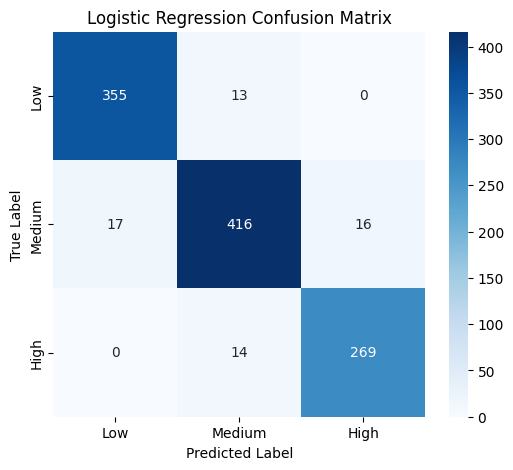

In [16]:
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**ROC Curve**

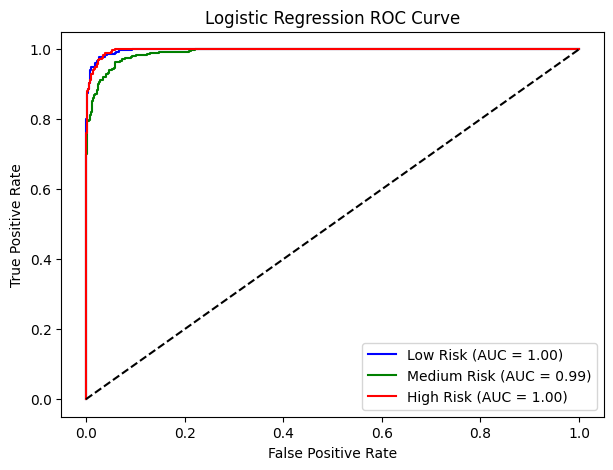

In [17]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_log[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

colors = ["blue","green","red"]
labels = ["Low Risk","Medium Risk","High Risk"]

for i, color in enumerate(colors):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

**Store Model Results**

In [26]:
model_results = pd.DataFrame(columns=[
    "Model",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
])

model_results.loc[len(model_results)] = [
    "Logistic Regression",
    log_accuracy,
    log_precision,
    log_recall,
    log_f1
]

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,94.545455,94.539035,94.545455,94.539282


### Logistic Regression Model Results

The Logistic Regression model was trained as a baseline classifier using the selected site features. The model achieved the following performance:

- **Accuracy:** 94.55%
- **Precision:** 94.54%
- **Recall:** 94.55%
- **F1 Score:** 94.54%

These results indicate that the Logistic Regression model performs very well in predicting cardiovascular risk categories even with a reduced set of user-input features.

The confusion matrix shows that most samples were correctly classified across all three risk categories (Low, Medium, and High). Only a small number of misclassifications occurred, primarily between the Medium and neighboring classes, which is expected in multi-class classification problems where class boundaries may overlap.

The ROC curves further confirm the strong predictive capability of the model. The Area Under the Curve (AUC) values for all three classes are very close to 1.0, indicating excellent class separability.

Overall, the Logistic Regression model provides strong baseline performance for the site-feature model and demonstrates that a reduced set of clinically relevant features can still produce highly accurate predictions.

### Random Forest Model

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)

**Evaluate Random Forest**

In [20]:
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf,
    "Random Forest"
)


Random Forest Performance Metrics
----------------------------------
Accuracy : 91.55 %
Precision: 91.6 %
Recall   : 91.55 %
F1 Score : 91.56 %


**Confusion Matrix**

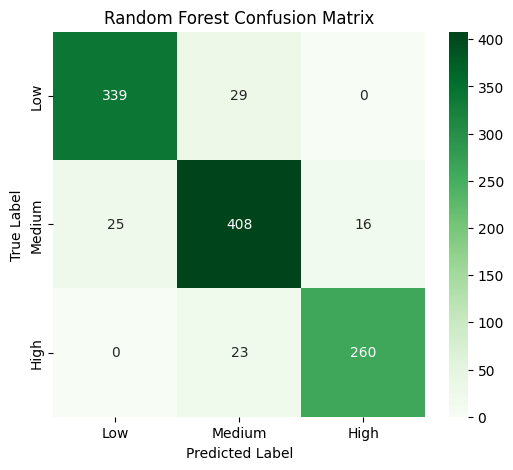

In [22]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap="Greens",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**ROC Curve**

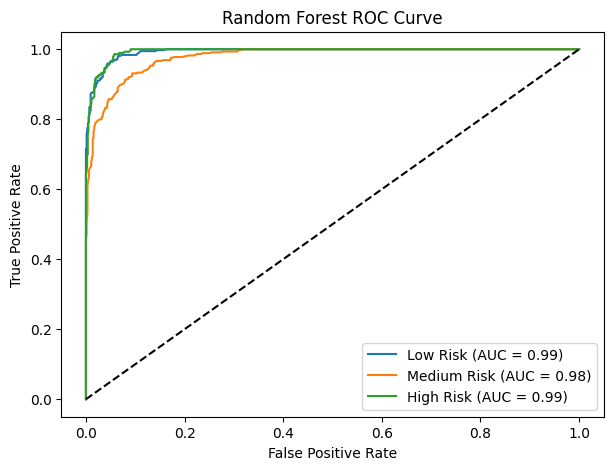

In [23]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

for i, color in enumerate(["blue","green","red"]):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

**Store Results**

In [27]:
# Store Random Forest Results

new_row = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy (%)": [rf_accuracy],
    "Precision (%)": [rf_precision],
    "Recall (%)": [rf_recall],
    "F1 Score (%)": [rf_f1]
})

model_results = pd.concat([model_results, new_row], ignore_index=True)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,94.545455,94.539035,94.545455,94.539282
1,Random Forest,91.545455,91.596632,91.545455,91.560998


### Random Forest Model Results

The Random Forest classifier was trained using the selected site features to evaluate whether an ensemble tree-based model could improve predictive performance compared to the Logistic Regression baseline.

The model achieved the following performance:

• Accuracy: 91.55%  
• Precision: 91.60%  
• Recall: 91.55%  
• F1 Score: 91.56%

The confusion matrix shows that the majority of predictions were correctly classified across all three cardiovascular risk categories. However, a slightly higher number of misclassifications occurred compared to the Logistic Regression model, particularly between the Low and Medium risk categories.

The ROC curves indicate strong classification capability, with Area Under the Curve (AUC) values close to 1.0 for all classes. This confirms that the Random Forest model can effectively distinguish between different cardiovascular risk levels.

Despite its strong performance, the Random Forest model achieved slightly lower accuracy than the Logistic Regression baseline in this dataset. This suggests that the relationships between the selected site features and the target variable may be largely linear, allowing the Logistic Regression model to perform very efficiently.

Overall, Random Forest provides a strong ensemble-based alternative model, but in this experiment it does not outperform the baseline Logistic Regression classifier.

## Gradient Boosting Model

In [28]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

y_prob_gb = gb_model.predict_proba(X_test)

**Evaluate Model**

In [29]:
gb_accuracy, gb_precision, gb_recall, gb_f1 = evaluate_model(
    y_test,
    y_pred_gb,
    y_prob_gb,
    "Gradient Boosting"
)


Gradient Boosting Performance Metrics
----------------------------------
Accuracy : 93.27 %
Precision: 93.33 %
Recall   : 93.27 %
F1 Score : 93.29 %


**Confusion Matrix**

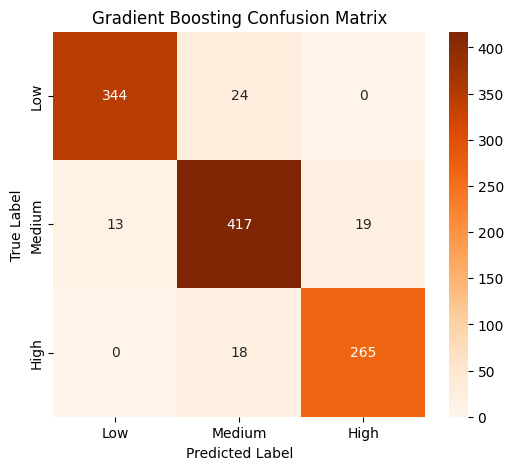

In [30]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt='d',
    cmap="Oranges",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**ROC Curve**

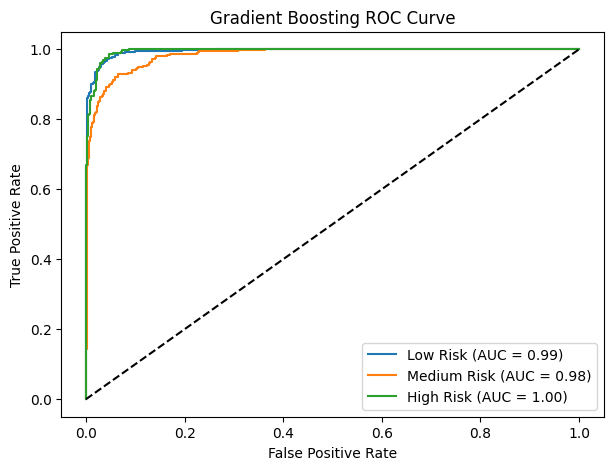

In [31]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

for i, color in enumerate(["blue","green","red"]):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("Gradient Boosting ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

**Store Results**

In [32]:
new_row = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Accuracy (%)": [gb_accuracy],
    "Precision (%)": [gb_precision],
    "Recall (%)": [gb_recall],
    "F1 Score (%)": [gb_f1]
})

model_results = pd.concat([model_results, new_row], ignore_index=True)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,94.545455,94.539035,94.545455,94.539282
1,Random Forest,91.545455,91.596632,91.545455,91.560998
2,Gradient Boosting,93.272727,93.325579,93.272727,93.287221


### Gradient Boosting Model Results

The Gradient Boosting classifier was trained using the selected site features to evaluate whether boosting-based ensemble learning could improve predictive performance.

The model achieved the following results:

• Accuracy: 93.27%  
• Precision: 93.33%  
• Recall: 93.27%  
• F1 Score: 93.29%

The confusion matrix indicates that the model correctly classified the majority of samples across the three cardiovascular risk categories. A small number of misclassifications occurred between the Medium and High risk categories, which is expected because these classes may share similar feature characteristics.

The ROC curves show strong class separation ability. The Area Under the Curve (AUC) values are approximately:

• Low Risk: 0.99  
• Medium Risk: 0.98  
• High Risk: 1.00  

These high AUC values indicate that the Gradient Boosting model has excellent capability in distinguishing between the three risk classes.

When compared with previous models, the Gradient Boosting classifier achieved higher accuracy than Random Forest but slightly lower accuracy than Logistic Regression in this dataset.

Overall, Gradient Boosting provides strong predictive performance and confirms that the reduced set of site features still maintains high classification capability.

### XGBoost Model

In [33]:
xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)

Evaluate XGBoost

In [34]:
xgb_accuracy, xgb_precision, xgb_recall, xgb_f1 = evaluate_model(
    y_test,
    y_pred_xgb,
    y_prob_xgb,
    "XGBoost"
)


XGBoost Performance Metrics
----------------------------------
Accuracy : 92.27 %
Precision: 92.31 %
Recall   : 92.27 %
F1 Score : 92.28 %


**Confusion Matrix**

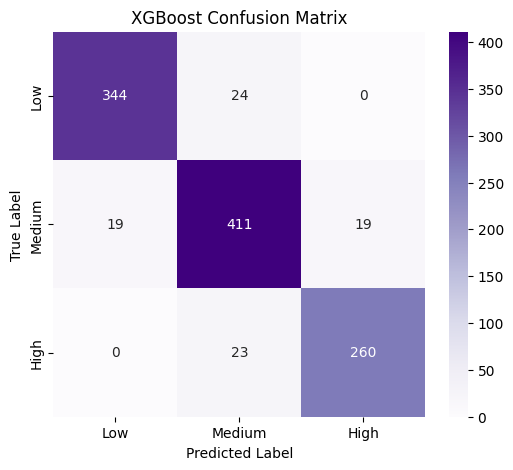

In [35]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap="Purples",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**ROC Curve**

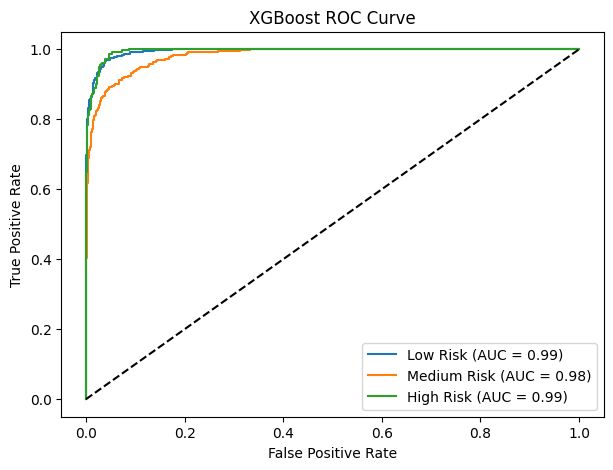

In [36]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(7,5))

for i, color in enumerate(["blue","green","red"]):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.title("XGBoost ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

**Store Results**

In [37]:
new_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy (%)": [xgb_accuracy],
    "Precision (%)": [xgb_precision],
    "Recall (%)": [xgb_recall],
    "F1 Score (%)": [xgb_f1]
})

model_results = pd.concat([model_results, new_row], ignore_index=True)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,94.545455,94.539035,94.545455,94.539282
1,Random Forest,91.545455,91.596632,91.545455,91.560998
2,Gradient Boosting,93.272727,93.325579,93.272727,93.287221
3,XGBoost,92.272727,92.308134,92.272727,92.284109


### XGBoost Model Results

The XGBoost classifier was trained to evaluate the performance of a gradient boosting based ensemble model using the selected site features.

The model achieved the following performance:

• Accuracy: 92.27%  
• Precision: 92.31%  
• Recall: 92.27%  
• F1 Score: 92.28%

The confusion matrix shows that the majority of samples were correctly classified across all three cardiovascular risk categories. A small number of misclassifications occurred mainly between the Medium and High risk categories, which is expected because these categories may share overlapping characteristics in some clinical features.

The ROC curves further confirm the strong predictive capability of the model. The Area Under the Curve (AUC) values are close to 1.0 for all three classes, indicating excellent discrimination between Low, Medium, and High cardiovascular risk levels.

Although XGBoost is generally considered a powerful model for tabular datasets, in this experiment its performance is slightly lower than the Logistic Regression and Gradient Boosting models. This suggests that the relationships between the selected site features and the target variable may be relatively linear in nature.

Overall, the XGBoost model demonstrates strong predictive performance and confirms that the selected site features are sufficient to accurately predict cardiovascular risk levels.

### Artificial Neural Network (ANN)
To further evaluate model performance, an Artificial Neural Network (ANN) was implemented. Neural networks are capable of learning complex non-linear relationships between input features and the target variable, making them suitable for classification tasks in healthcare prediction systems.

The neural network architecture used in this study consists of the following layers:

• **Input Layer:**  
The input layer receives the selected site features used for prediction (8 input variables).

• **First Hidden Layer:**  
32 neurons with ReLU (Rectified Linear Unit) activation were used to capture nonlinear relationships between the input features and cardiovascular risk categories.

• **Dropout Layer (0.3):**  
A dropout rate of 0.3 was applied to reduce overfitting by randomly disabling neurons during training.

• **Second Hidden Layer:**  
16 neurons with ReLU activation were used to further learn intermediate feature representations and improve the model's ability to capture complex patterns.

• **Dropout Layer (0.2):**  
An additional dropout layer was used to improve generalization and reduce model dependency on specific neurons.

• **Output Layer:**  
The output layer consists of 3 neurons with Softmax activation, corresponding to the three cardiovascular risk categories:
Low Risk, Medium Risk, and High Risk.

The Softmax activation function converts the output into probability distributions, allowing the model to assign a probability score for each risk category.

This architecture balances model complexity and generalization capability, allowing the neural network to learn meaningful patterns without excessive overfitting.

**Build Neural Network**

In [38]:
ann_model = Sequential()

ann_model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
ann_model.add(Dropout(0.3))

ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dropout(0.2))

ann_model.add(Dense(3, activation='softmax'))

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Train ANN**

In [39]:
history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5727 - loss: 0.9019 - val_accuracy: 0.7943 - val_loss: 0.6163
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7670 - loss: 0.5595 - val_accuracy: 0.8852 - val_loss: 0.3672
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8324 - loss: 0.4231 - val_accuracy: 0.9057 - val_loss: 0.2779
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8429 - loss: 0.3649 - val_accuracy: 0.9102 - val_loss: 0.2397
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8727 - loss: 0.3190 - val_accuracy: 0.9057 - val_loss: 0.2205
Epoch 6/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8662 - loss: 0.3144 - val_accuracy: 0.9159 - val_loss: 0.2086
Epoch 7/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8724 - loss: 0.2964 - val_accuracy: 0.9125 - val_loss: 0.1976
Epoch 8/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8776 - loss: 0.2852 - val_accuracy: 0.

**Predict**

In [40]:
y_prob_ann = ann_model.predict(X_test_scaled)

y_pred_ann = np.argmax(y_prob_ann, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


**Evaluate ANN**

In [41]:
ann_accuracy, ann_precision, ann_recall, ann_f1 = evaluate_model(
    y_test,
    y_pred_ann,
    y_prob_ann,
    "Artificial Neural Network"
)


Artificial Neural Network Performance Metrics
----------------------------------
Accuracy : 94.27 %
Precision: 94.29 %
Recall   : 94.27 %
F1 Score : 94.28 %


**Confusion Matrix**

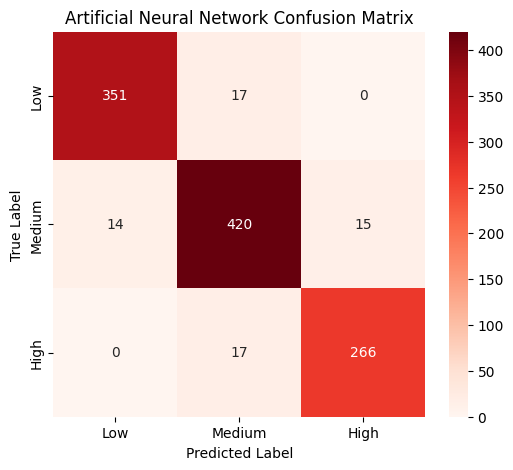

In [42]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_ann,
    annot=True,
    fmt='d',
    cmap="Reds",
    xticklabels=["Low","Medium","High"],
    yticklabels=["Low","Medium","High"]
)

plt.title("Artificial Neural Network Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Store Results**

In [43]:
new_row = pd.DataFrame({
    "Model": ["Artificial Neural Network"],
    "Accuracy (%)": [ann_accuracy],
    "Precision (%)": [ann_precision],
    "Recall (%)": [ann_recall],
    "F1 Score (%)": [ann_f1]
})

model_results = pd.concat([model_results, new_row], ignore_index=True)

model_results

,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Logistic Regression,94.545455,94.539035,94.545455,94.539282
1,Random Forest,91.545455,91.596632,91.545455,91.560998
2,Gradient Boosting,93.272727,93.325579,93.272727,93.287221
3,XGBoost,92.272727,92.308134,92.272727,92.284109
4,Artificial Neural Network,94.272727,94.286602,94.272727,94.277658


### Artificial Neural Network Model Results

The Artificial Neural Network (ANN) model was trained to evaluate whether a deep learning based model could improve prediction performance compared to the previously implemented machine learning models.

The ANN achieved the following performance:

• Accuracy: 94.27%  
• Precision: 94.29%  
• Recall: 94.27%  
• F1 Score: 94.28%

The confusion matrix shows that the majority of samples were correctly classified across all three cardiovascular risk categories (Low, Medium, and High). Only a small number of misclassifications occurred, mainly between the Medium and High risk classes, which is expected in multi-class classification problems where class boundaries may overlap.

These results demonstrate that the neural network was able to learn meaningful patterns from the selected site features and achieve strong predictive performance. The use of dropout layers helped reduce overfitting while maintaining good generalization ability on the test dataset.

Overall, the ANN model provides highly competitive performance and confirms that a reduced set of user-input features can still produce accurate cardiovascular risk predictions.

### Model Performance Comparison

To evaluate the predictive capability of the selected site features, multiple machine learning and deep learning models were trained and compared.

The results show that Logistic Regression achieved the highest accuracy (94.55%), followed closely by the Artificial Neural Network (94.27%). Gradient Boosting, XGBoost, and Random Forest also demonstrated strong performance but slightly lower accuracy.

The strong performance of Logistic Regression suggests that the relationships between the selected site features and cardiovascular risk categories may be largely linear. In such cases, simpler models can perform as effectively as more complex models.

The Artificial Neural Network achieved nearly equivalent performance, confirming that the selected feature set contains sufficient predictive information for accurate classification.

Overall, the results demonstrate that the reduced set of site features can still achieve very high prediction accuracy, making them suitable for use in the web-based cardiovascular risk prediction system.

### Final Model Selection for Deployment

Based on the model comparison results, Logistic Regression achieved the highest prediction accuracy (94.55%) among all evaluated models. The Artificial Neural Network produced a similar accuracy (94.27%), but neural networks are generally less interpretable and function as black-box models.

In healthcare prediction systems, interpretability and transparency are important because users and practitioners must understand the factors influencing the prediction.

Logistic Regression provides several advantages:

• Highest classification accuracy in this experiment  
• High interpretability through model coefficients  
• Simpler and more stable deployment  
• Compatibility with explainable AI techniques such as SHAP and LIME  

For these reasons, Logistic Regression was selected as the final model for the web-based cardiovascular risk prediction system.

### Model Accuracy Comparison

/tmp/ipykernel_243/3295612455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


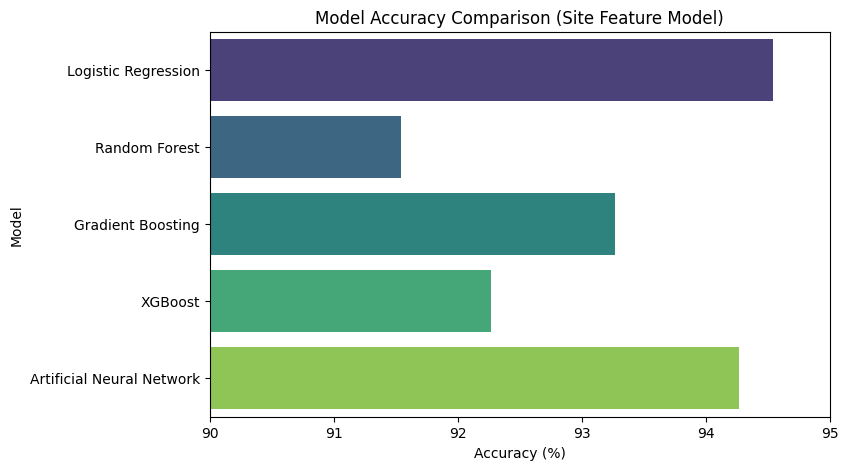

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x="Accuracy (%)",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison (Site Feature Model)")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")

plt.xlim(90,95)

plt.show()

The bar chart above compares the prediction accuracy of all evaluated models using the selected site features.

Logistic Regression achieved the highest accuracy (94.55%), followed closely by the Artificial Neural Network (94.27%). Gradient Boosting, XGBoost, and Random Forest also demonstrated strong predictive capability but slightly lower accuracy.

These results indicate that the selected set of user-input features contains sufficient predictive information for accurate cardiovascular risk classification.

Interestingly, the Logistic Regression model performed better than more complex models such as ensemble methods and neural networks. This suggests that the relationships between the selected features and cardiovascular risk categories may be largely linear, allowing simpler models to perform very effectively.

Based on these results, Logistic Regression was selected as the final model for deployment in the web-based prediction system.

**ROC Curve Comparison**

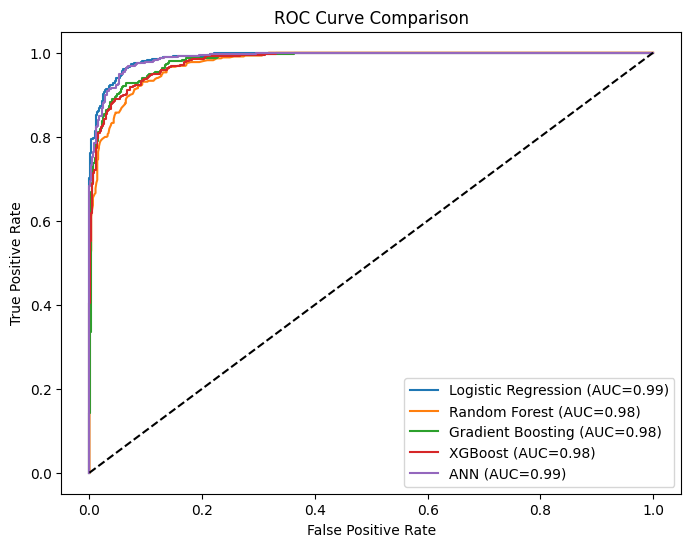

In [45]:
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": y_prob_log,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb,
    "XGBoost": y_prob_xgb,
    "ANN": y_prob_ann
}

for name, probs in models.items():

    fpr, tpr, _ = roc_curve(
        label_binarize(y_test, classes=[0,1,2])[:,1],
        probs[:,1]
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

The ROC curve comparison illustrates the classification performance of all models across different decision thresholds.

All models achieved very high AUC values, indicating strong capability in distinguishing between cardiovascular risk categories. Logistic Regression and the Artificial Neural Network demonstrate the best overall performance, with ROC curves closest to the top-left corner of the plot.

This confirms that the selected site features are highly informative and allow accurate classification of cardiovascular risk levels even with a reduced feature set.

### SHAP Explainability

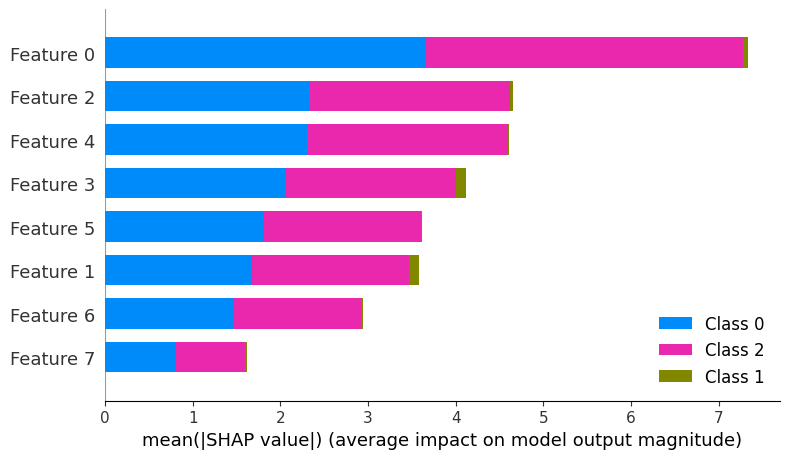

In [46]:
explainer = shap.Explainer(log_model, X_train_scaled)

shap_values = explainer(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

SHAP (SHapley Additive exPlanations) was used to interpret the contribution of each feature to the model predictions.

The SHAP summary plot shows the overall impact of each feature on the cardiovascular risk prediction. Features with higher SHAP values have a stronger influence on the prediction outcome.

From the visualization, systolic blood pressure, cholesterol level, age, BMI, and smoking status appear as the most influential factors affecting cardiovascular risk prediction.

These results align with established medical knowledge, confirming that the model identifies clinically meaningful predictors of heart disease risk.

### LIME Local Explanation

In [47]:
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=["Low","Medium","High"],
    mode="classification"
)

sample_index = 0

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[sample_index].values,
    log_model.predict_proba,
    num_features=8
)

lime_exp.show_in_notebook(show_table=True)

LIME (Local Interpretable Model-Agnostic Explanations) was used to explain individual predictions made by the model.

For a selected patient instance, LIME identifies the features that most strongly influenced the predicted cardiovascular risk category.

The visualization highlights both positive and negative contributions of features to the final prediction. This allows users to understand why the model predicted a particular risk level for a specific patient.

Such local explanations are valuable in healthcare applications because they provide transparency and help users interpret model predictions.

### Site Model vs Full Model Comparison

**Comparison with Full Feature Model**

The performance of the site-feature model was compared with the previously developed full-feature research model.

The full-feature model achieved approximately 94% accuracy, while the site-feature model achieved 94.55% accuracy using only eight user-input variables.

This result demonstrates that a carefully selected subset of clinically relevant features can achieve predictive performance comparable to models that use a larger number of variables.

Reducing the number of required inputs simplifies the user interaction process and improves the practicality of the web-based prediction system while maintaining high predictive accuracy.

### Conclusion

This notebook evaluated whether a reduced set of user-input features could still produce accurate cardiovascular risk predictions.

Multiple machine learning models were trained and evaluated, including Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and an Artificial Neural Network.

Among these models, Logistic Regression achieved the highest prediction accuracy (94.55%) while also providing strong interpretability and simplicity. As a result, Logistic Regression was selected as the final model for deployment in the web-based cardiovascular risk prediction system.

Explainable AI techniques such as SHAP and LIME were applied to interpret both global feature importance and individual predictions. These explanations enhance transparency and help users understand the factors influencing cardiovascular risk predictions.

Overall, the results demonstrate that a carefully selected set of user-friendly input features can achieve high prediction accuracy while maintaining model interpretability and usability for real-world healthcare applications.